In [111]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency as chi2
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_curve, auc # For the model evaluation

In [112]:
job_attrition = pd.read_csv("C:/Users/SAGBO/Downloads/Attrition Data.csv")
job_attrition.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [113]:
job_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   object
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   object
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 149.4+ KB


In [114]:
# Recode certain columns into new one
job_attrition["Education_level"] = job_attrition["Education"].replace({1:"Below College", 2 : "College", 3 : "Bachelor", 4 : "Master", 5 : "Doctor"})
job_attrition["job_satisfaction"] = job_attrition["JobSatisfaction"].replace({1:"Low", 2: "Medium", 3: "High", 4:"Very High"})
job_attrition["worklifebalance"] = job_attrition["WorkLifeBalance"].replace({1: "Bad", 2: "Good", 3: "Better", 4: "Best"})
job_attrition["environ_satisfaction"] = job_attrition["EnvironmentSatisfaction"].replace({1: "Low", 2: "Medium", 3: "High", 4: "Very High"})

Problem Statement
Our client is ABC a leading firm and is doing well in the sector. It is recently facing a steep increase in its employee attrition . Employee attrition has gone up from 14% to 25% in the last 1 year . We are asked to prepare a strategy to immediately tackle this issue such that the firm’s business is not hampered and also to propose an efficient employee satisfaction program for long run. Currently, no such program is in place . Further salary hikes are not an option.

Data Description
The dataset consists of 14710 observations and 8 variables. Each row in dataset represents an employee; each column contains employee attributes:

Independent Variables were:
Age: Age of employees,
Department: Department of work,
Distance from home,
Education: 1-Below College; 2-College; 3-Bachelor; 4-Master; 5-Doctor;
Education Field
Environment Satisfaction: 1-Low; 2-Medium; 3-High; 4-Very High;
Job Satisfaction: 1-Low; 2-Medium; 3-High; 4-Very High;
Marital Status,
Monthly Income,
Num Companies Worked: Number of companies worked prior to IBM,
Work Life Balance: 1-Bad; 2-Good; 3-Better; 4-Best;
Years At Company: Current years of service in IBM
Dependent Variable was:
Attrition: Employee attrition status(0 or 1)

In [115]:
job_attrition["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In that company the part of employee attrition is 16.12 %, meaning that 16.12% of their employees leave the organization without being immediately replaced over a specific period of time.

In [116]:
attrition = job_attrition[job_attrition["Attrition"]=="Yes"]["Attrition"].count()
employee = job_attrition["Attrition"].value_counts().sum()
# Let's compute the attrition rate
# First we will compute the average employee
aver = (employee + (employee - attrition)) / 2
# Then let's compute the attrition rate
rate = (attrition / aver) * 100
print(rate)


17.53607103218646


The attrition rate for the year in that company is 17.54%

In [117]:
marital_status = job_attrition[job_attrition["Attrition"] == "Yes"]["MaritalStatus"].value_counts(normalize=True) * 100
print(marital_status)

MaritalStatus
Single      50.632911
Married     35.443038
Divorced    13.924051
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Attrition according to the marital status')

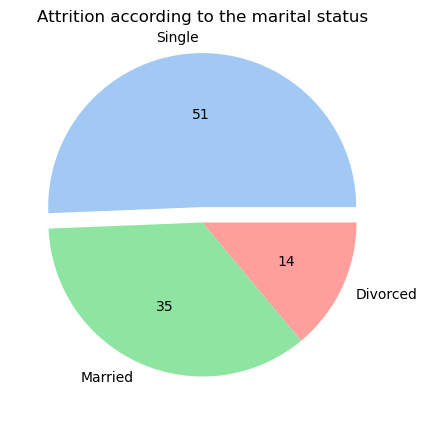

In [118]:
plt.figure(figsize=(5, 5))
explode = [.1, 0, 0]
labels = ["Single", "Married", "Divorced"]
colors=sns.color_palette("pastel6")
plt.pie(marital_status.values, explode=explode, labels=labels, autopct="%2.f", colors=colors)
plt.title("Attrition according to the marital status")

Over the half of the employees who left the company without being immediately replaced are single.

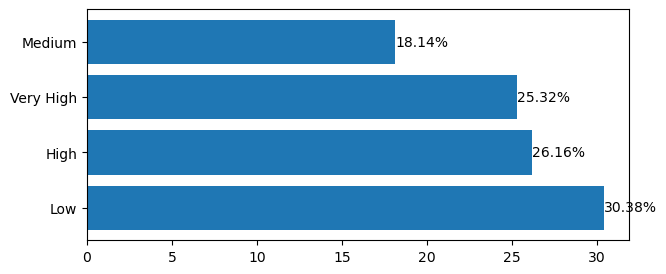

In [119]:
environ_satisfaction = job_attrition[job_attrition["Attrition"] == "Yes"]["environ_satisfaction"].value_counts(normalize=True) * 100
plt.figure(figsize=(7,3))
container = plt.barh(list(environ_satisfaction.index), list(environ_satisfaction.values), align="center")
plt.bar_label(container=container, fmt="%.2f%%")
plt.show()

Taking into account the graphic, 30% of employees who left the organization have a low environment satisfaction. But we also noticed that over the half of them have at least a high environment satisfaction. So we can not explain employee attrition solely we with environment satisfaction.

In [120]:
# Performed groupby
education = (
    job_attrition
             .groupby(["Attrition", "Education_level"])
             .size()
             .reset_index(name="Frequency"))
print(education)

  Attrition Education_level  Frequency
0        No        Bachelor        473
1        No   Below College        139
2        No         College        238
3        No          Doctor         43
4        No          Master        340
5       Yes        Bachelor         99
6       Yes   Below College         31
7       Yes         College         44
8       Yes          Doctor          5
9       Yes          Master         58


In [121]:
# The contingency table
table = pd.crosstab(job_attrition["Education_level"] ,job_attrition["Attrition"])
# The chi2 test
stat, p, dof, expected = chi2(table)
print(p)

0.5455253376565949


After running the chi2 test, p-value is 0.55 (> 0.05) showing that there is a relationship between employee attrition and their education level.
 Let's present that relationship through the following graphic.

<Axes: xlabel='Education_level', ylabel='Frequency'>

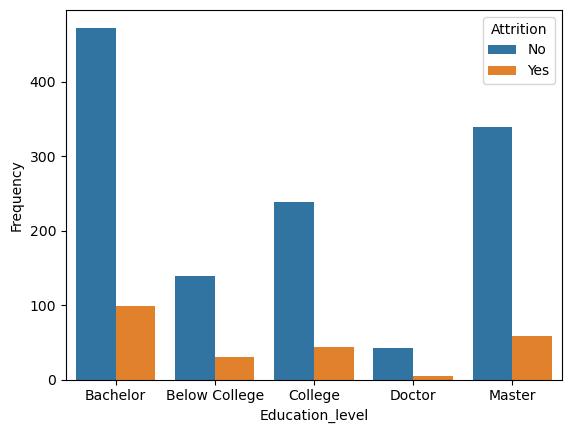

In [122]:
sns.barplot(data=education, x="Education_level", y="Frequency", hue="Attrition")

From this output, we can point out that the major part of the employees have bachelor's degree and among them are 42% of numbers the of the employees who left without being replaced.

In [123]:
# Job satisfaction
table1 = pd.crosstab(job_attrition["job_satisfaction"], job_attrition["Attrition"])
# Chi2 test on the table
stat, p1, dof, expected = chi2(table1)
print(p1)

0.0005563004510387556


In [124]:
# Department
table2 = pd.crosstab(job_attrition["Department"], job_attrition["Attrition"])
# Chi2 test on the table
stat, p2, dof, expected = chi2(table2)
print(p2)

0.004525606574479633


In [125]:
# Department
table2 = pd.crosstab(job_attrition["EducationField"], job_attrition["Attrition"])
# Chi2 test on the table
stat, p3, dof, expected = chi2(table2)
print(p3)

0.006773980139025212


p-value = 0.00056 < 0.05, there is no relationship between employee attrition and job satisfaction. Likewise Job satisfaction, Education Field, the department the employee is working are not linked to job attrition.

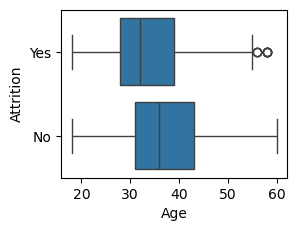

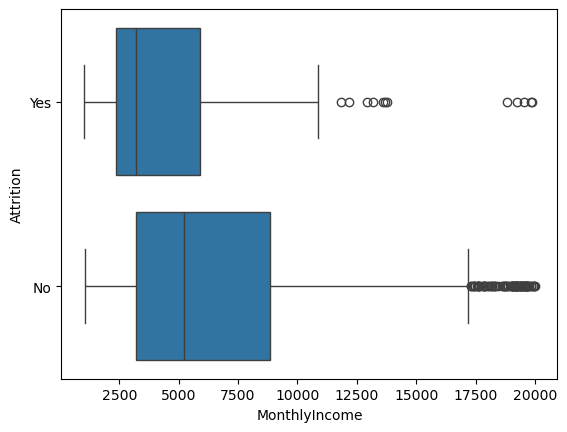

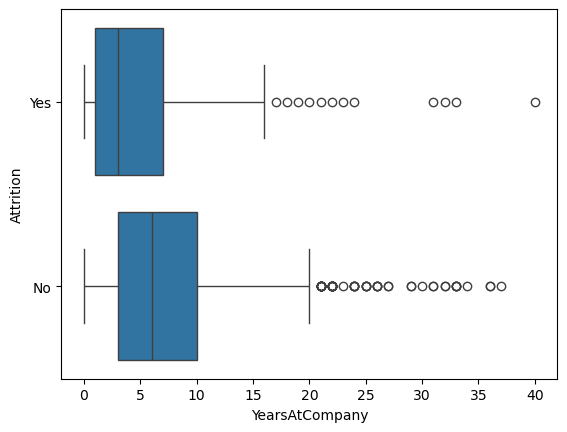

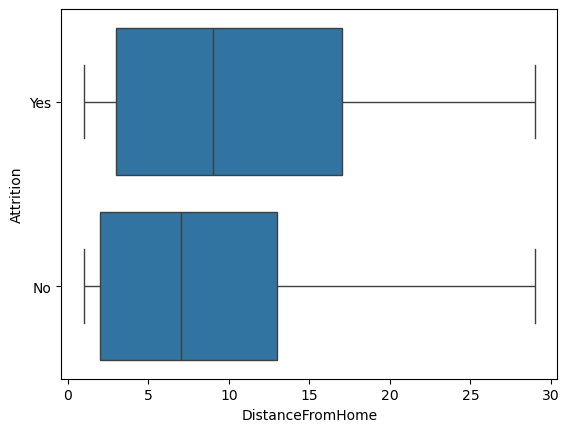

In [126]:
# Relationship between employee Age, MonthlyIncome, YearsAtCompany, DistanceFromHome
fig = plt.figure()
variables = ["Age", "MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]
for i, var in enumerate(variables):
    ax = fig.add_subplot(2, 2, i+1)
    sns.boxplot(x=var, y="Attrition", data=job_attrition)
    plt.show()


Compared to those employees who stayed in the organization, the interquartile ranges for employees who left when we take into account the age, monthly income, years at the company are narrowed and the median values are lower. This means that they are young, with lower income and less experience in the company, then less committed to the company growth.

Nevertheless, the interquartile range for employees who left is larger and the median distance from home is higher than those of employee who remain in the company.


In [127]:
job_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   object
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   object
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
 13  Education_level          1470 non-null   object
 14  job_satisfaction         1470 non-null  

In [128]:
# Logistic regression
# Variables selection
X = job_attrition[["Age", "DistanceFromHome", "environ_satisfaction", "job_satisfaction", "Education_level", "MonthlyIncome", "worklifebalance", "YearsAtCompany", "MaritalStatus"]]
y = job_attrition["Attrition"]
# Transform categorical variables into dummies
y = y.map({"No": 0, "Yes": 1})
X = pd.get_dummies(X, columns=["environ_satisfaction", "job_satisfaction", "Education_level", "worklifebalance", "MaritalStatus"], drop_first=True)
# Select boolean variables
bool_columns = X.select_dtypes(include='bool').columns
X[bool_columns] = X[bool_columns].astype(int)
# Add the constant for the intercept
X = sm.add_constant(X)

In [129]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   const                           1470 non-null   float64
 1   Age                             1470 non-null   int64  
 2   DistanceFromHome                1470 non-null   int64  
 3   MonthlyIncome                   1470 non-null   int64  
 4   YearsAtCompany                  1470 non-null   int64  
 5   environ_satisfaction_Low        1470 non-null   int64  
 6   environ_satisfaction_Medium     1470 non-null   int64  
 7   environ_satisfaction_Very High  1470 non-null   int64  
 8   job_satisfaction_Low            1470 non-null   int64  
 9   job_satisfaction_Medium         1470 non-null   int64  
 10  job_satisfaction_Very High      1470 non-null   int64  
 11  Education_level_Below College   1470 non-null   int64  
 12  Education_level_College         14

In [130]:
# Split the dataset into test and train dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

In [131]:
# Train the model
model = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.396825
         Iterations 7


In [132]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1176
Model:                          Logit   Df Residuals:                     1156
Method:                           MLE   Df Model:                           19
Date:                Sat, 27 Dec 2025   Pseudo R-squ.:                  0.1246
Time:                        11:26:27   Log-Likelihood:                -466.67
converged:                       True   LL-Null:                       -533.07
Covariance Type:            nonrobust   LLR p-value:                 4.294e-19
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.4726      0.562     -0.841      0.400      -1.573       0.628
Age                               -0.0227      0.011     -2.029      0.

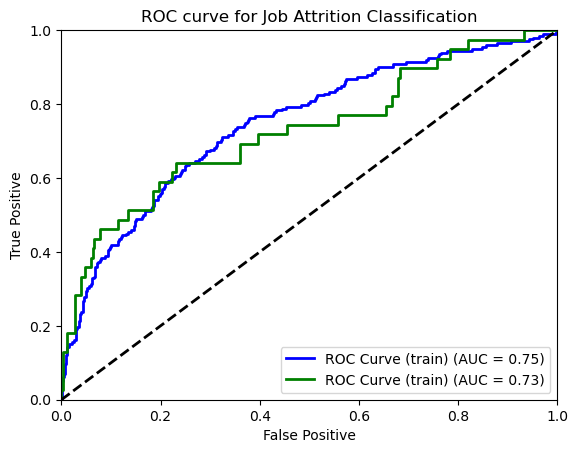

In [133]:
# Evaluate the model prediction
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

fpr_train, tpr_train, threshold_train = roc_curve(y_train, y_train_pred)
roc_train_auc = auc(fpr_train, tpr_train)

fpr_test, tpr_test, threshold_test = roc_curve(y_test, y_test_pred)
roc_test_auc = auc(fpr_test, tpr_test)

plt.figure()
plt.plot(fpr_train, tpr_train, color="blue", lw=2, label='ROC Curve (train) (AUC = %0.2f)' % roc_train_auc)
plt.plot(fpr_test, tpr_test, color="green", lw=2, label='ROC Curve (test) (AUC = %0.2f)' % roc_test_auc)
plt.plot([0, 1], [0, 1], lw=2, color="black", linestyle="--")
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC curve for Job Attrition Classification")
plt.legend(loc="lower right")
plt.show()


The Likelihood Ratio test is highly significant (LLR p-value < 0.05), indicating that the model including the explanatory variables provides a statistically significant improvement than the null model with the intercept only. This result confirms the overall statistical relevance of the model in explaining employee attrition.

Moreover the area under the Receiver Operating Characteristic (ROC) curve was 0.75, indicating good discriminative ability of the model. Tjis suggest that the model is capable of correctly ranking employees in terms of their risk of attrition in approximately 75% of cases, demonstrating performance well above chance level.

The result of model showed that among the explanatory variables, the age, the distance from home, the monthly income, the environment satisfaction, the job satisfaction, the education level, the work life balance and the marital status explain the job attrition (as the p-value associated with each of these variables are lower than 0.05). 
In fact, each additional year of age reduces the odds of attrition, holding the other variables constant. This implies that younger employees are more likely to leave the organization.
For the distance from home in contrast, each additional distance increases the porobability of attrition, meaning that employees who live far from the company are more likely to leave the company.
Also employees with lower environment and satisfaction are more likely to leave the company. 
Moreover, employees who are single more probable to leave without being replaced. 
We can also point out that an increase of the monthly income reduce the probability of employee attrition.

The result of the logstic regression analysis indicate that job attrition is significantly associated with several individual and job-related characteristics. Specifically, age, distance from home, monthly income, environmental satisfaction, job satisfaction, work-life balance, and marital status emerge as significanr determinants of employee attrition, as evidenced by p-vlues below the 0.05 significance level.

The findings show that age is negatively associated with attrition as each additional year of age reduces the odds of leaving the organization, holding all others factors constant. This suggest that younger employees are more likely to experience job attrition compared to older employees.

In contrast, distance from home has a positive effect on attrition. Employees who live farther from the company have a higher likelihood of leaving the organization, highlighting the role of commuting burden in turnover decisions. 

Furthermore, work enrionment and job satisfaction play a crucial role in employee retention. Employees reporting low environmental satisfaction and low job satisfaction exhibit significantly higher odds of attrition compared to those with higher satifaction levels, underscring the inportance of favorable working conditions.

The results also reveal a strong association between marital status and attrition. Singla employees are significantly more likely to leave the oraganization compared to tehir counterparts, suggesting differences in carrer mobility and personal constraints.

It also shows that work-life balance is a sigificant protective factor against attrition. Employees reporting a better work-life balance are significantly less liekly to leave the organization compared to employees with low work-life balance.

Finally, monthly income is inversely related to attrition. An increase in income is associated with a reduction in the probability of employee turnover, indicating that competitive compensation serves as a protective factor against attrition.

Overall, these findings confirm that employee attrition is multifactorial phenomenon, driven by a combination of demographic characteristics, economic factors, job conditions, and work-life balance considerations.